In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)
#from google.colab import drive
#drive.mount('/content/drive')

# Baseline model: logistic regressor

---
#### Loading the data and preprocessing

In [2]:
#df = pd.read_parquet('/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/data_ml.parquet')
df = pd.read_parquet('./classification_ring/data/processed/data_ml.parquet')

df.head()

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,1u9c,A,172,,S,H,0.354,-1.001,-0.749,-0.228,...,-0.912,17.0,R,1,0,0,0,0,0,1
1,1u9c,A,184,,G,-,0.250,-2.102,-3.018,-0.384,...,-1.853,19.0,T,1,0,0,0,0,0,0
2,1u9c,A,10,,T,-,0.000,-1.252,2.751,-0.032,...,-3.242,12.0,M,1,0,0,0,0,0,0
3,1u9c,A,133,,V,T,0.021,-1.076,-0.664,-1.337,...,1.313,15.0,P,0,0,0,0,0,0,1
4,1u9c,A,146,,G,T,0.548,1.315,0.127,-0.384,...,2.064,6.0,G,1,0,0,0,0,0,0


#### Split train/test/validation by pdb_id

In [3]:
#print(df.columns.tolist())
#print(df.dtypes)
#looking at the column names

Defining the columns

In [4]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]

print("Label distribution:")
print(df[label_cols].sum().sort_values(ascending=False))

Label distribution:
HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


Spliting

In [5]:
#avoiding data leakage
pdb_ids = df['pdb_id'].unique().to_numpy()
print(f"Total unique PDBs: {len(pdb_ids)}")

#using 70% train, 15% val, 15% test
train_pdbs, temp_pdbs = train_test_split(pdb_ids, test_size=0.30, random_state=42)
val_pdbs, test_pdbs   = train_test_split(temp_pdbs, test_size=0.50, random_state=42)

train_df = df[df['pdb_id'].isin(train_pdbs)].reset_index(drop=True)
val_df   = df[df['pdb_id'].isin(val_pdbs)].reset_index(drop=True)
test_df  = df[df['pdb_id'].isin(test_pdbs)].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, {len(train_pdbs)} PDBs")
print(f"Val:   {len(val_df)} rows, {len(val_pdbs)} PDBs")
print(f"Test:  {len(test_df)} rows, {len(test_pdbs)} PDBs")

Total unique PDBs: 3827
Train: 999083 rows, 2678 PDBs
Val:   238810 rows, 574 PDBs
Test:  214518 rows, 575 PDBs


Preparation of X and Y

In [6]:
feature_cols = num_features + cat_features

X_train = train_df[feature_cols]
Y_train = train_df[label_cols]

X_val = val_df[feature_cols]
Y_val = val_df[label_cols]

X_test = test_df[feature_cols]
Y_test = test_df[label_cols]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (999083, 22)
Y_train shape: (999083, 7)


Preproccessing to clean the features

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer # apply different preprocessing steps to different columns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier # train a separate classifier for each output label (one vs rest)
from sklearn.impute import SimpleImputer # fills in missing values with a specified strategy (mean, median, mode, etc.)
#Imputing was necessary because we of NaN vaues
# Numerical:impute with median then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical:impute with most frequent,then encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore' ensures that if a category appears in the test set that wasn't seen in the training set, it won't cause an error. Instead, it will be ignored and encoded as all zeros.
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

lr_model = MultiOutputClassifier(
    LogisticRegression(
        class_weight='balanced', # helps to handle class imbalance by adjusting the weights inversely proportional to class frequencies in the input data. Model learns to pay more attention to the minority class.
        max_iter=1000,
        random_state=42
    )
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lr_model)
    ],
    verbose = True # prints some logging, which might be useful to see the progress of the training
)

print("Pipeline built successfully")

Pipeline built successfully


Save preprocessed train/val/test to file for later usage

In [8]:
os.makedirs("classification_ring/data/processed", exist_ok=True)

train_df.to_parquet("classification_ring/data/processed/train.parquet", index=False)
val_df.to_parquet("classification_ring/data/processed/val.parquet", index=False)
test_df.to_parquet("classification_ring/data/processed/test.parquet", index=False)

print("Splits saved successfully.")
print("DO NOT touch test.parquet until final evaluation pliz!")

Splits saved successfully.
DO NOT touch test.parquet until final evaluation pliz!


---

#### Train

In [9]:
print("Training")
pipeline.fit(X_train, Y_train)
print("Training complete!")

Training
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   3.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  32.2s
Training complete!


Evaluation of validation set

In [10]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
Y_pred = pipeline.predict(X_val)

print("=" * 60)
print("For each Class Results on VALIDATION SET")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))
macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")

For each Class Results on VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.39      0.59      0.47     65125
     present       0.81      0.65      0.72    173685

    accuracy                           0.64    238810
   macro avg       0.60      0.62      0.60    238810
weighted avg       0.69      0.64      0.65    238810


--- VDW ---
              precision    recall  f1-score   support

      absent       0.56      0.58      0.57    117837
     present       0.57      0.55      0.56    120973

    accuracy                           0.56    238810
   macro avg       0.56      0.56      0.56    238810
weighted avg       0.56      0.56      0.56    238810


--- IONIC ---
              precision    recall  f1-score   support

      absent       1.00      0.90      0.94    233328
     present       0.18      0.99      0.31      5482

    accuracy                           0.90    238810
   macro avg       0.59      0.94      0.63 

---

## Evaluation metrics: MCC, BA, PR-curve and ROC

NOTE: here i used the test set, but just to familiarize with the metrics. We will need to perform **cross-validation**



### Benchmark MCC and Balanced Accuracy at varying threshold, for each class

In [11]:
target_names = label_cols


# get predicted probabilities for each class
y_proba_list = pipeline.predict_proba(X_test) # list of #target_names arrays, each of shape (n_samples, 2) containing yes/no probabilities

# column of probabilities for the "present" class (index 1) for each label
y_scores = np.array([proba[:, 1] for proba in y_proba_list]).T # shape (n_samples, n_labels)
print(y_scores.shape)
print(y_scores[:5])

(214518, 7)
[[6.30730160e-01 4.04556812e-01 9.64139870e-06 9.93648819e-10
  6.84911691e-12 2.55275602e-08 4.74830280e-03]
 [4.92170370e-01 6.16898686e-01 1.15576468e-03 5.01988970e-06
  4.46180478e-06 5.47943432e-14 1.51238189e-01]
 [4.88846591e-01 6.07129980e-01 1.92922070e-02 2.00162289e-06
  1.79062095e-08 8.93967770e-22 1.50725460e-01]
 [3.02112887e-01 6.16300538e-01 4.25516891e-06 1.54083505e-06
  2.55809067e-07 3.69005433e-13 3.18717530e-02]
 [5.37855848e-01 4.09213429e-01 7.89491572e-08 4.79751713e-07
  7.11454348e-05 3.13280958e-08 2.08117850e-01]]


In [12]:
thresholds = np.arange(0.00, 1.01, 0.01)

results = []

for class_idx, class_name in enumerate(target_names):
    
    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    y_score_class = y_scores[:, class_idx]
    
    for threshold in thresholds:
        
        y_pred_class = (y_score_class >= threshold).astype(int)
        
        mcc = matthews_corrcoef(y_true_class, y_pred_class)
        bal_acc = balanced_accuracy_score(y_true_class, y_pred_class)
        
        results.append({
            "class": class_name,
            "threshold": threshold,
            "MCC": mcc,
            "balanced_accuracy": bal_acc
        })

threshold_results = pd.DataFrame(results)

threshold_results.head()

,class,threshold,MCC,balanced_accuracy
0,HBOND,0.00,0.0,0.5
1,HBOND,0.01,0.0,0.5
2,HBOND,0.02,0.0,0.5
3,HBOND,0.03,0.0,0.5
4,HBOND,0.04,0.0,0.5


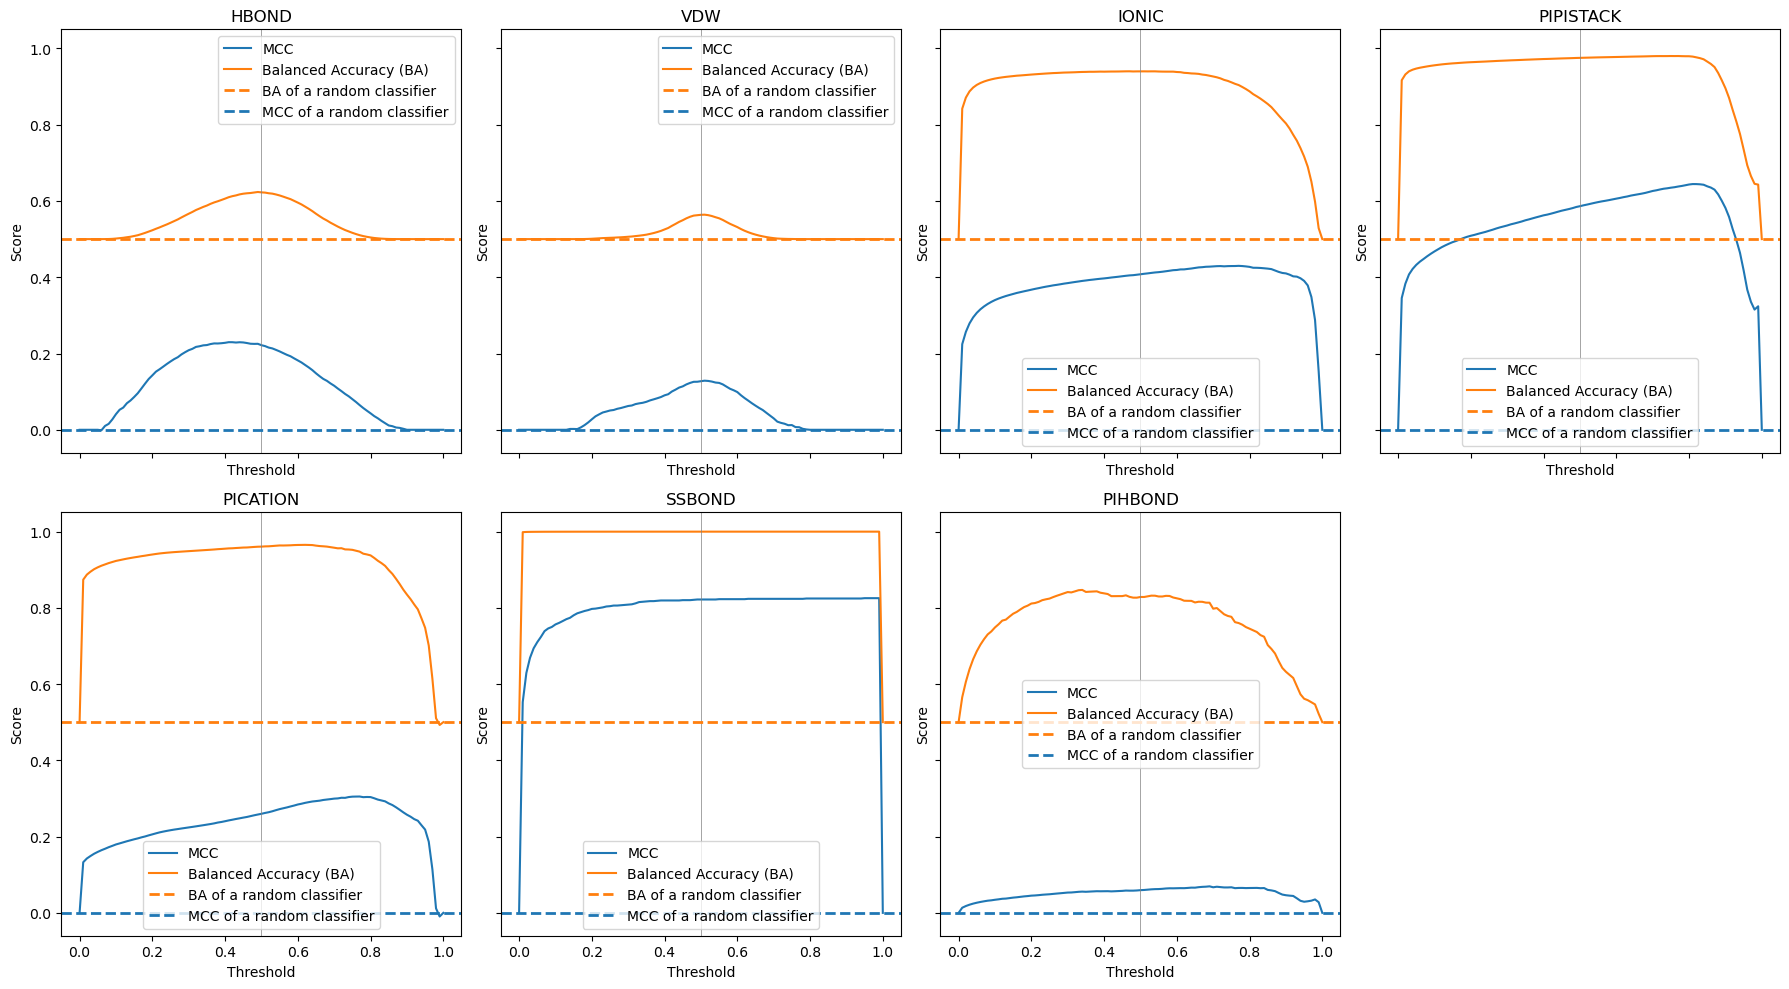

In [13]:
# plot MCC and balanced accuracy vs threshold for each class

fig, axes = plt.subplots(2, len(target_names)//2 + 1, figsize=(18, 10),
                         sharex=True, sharey=True)
axes = axes.flatten()

axes[-1].axis('off') 

for class_idx, class_name in enumerate(target_names):
    ax = axes[class_idx]
    class_results = threshold_results[threshold_results["class"] == class_name]
    ax.plot(class_results["threshold"], class_results["MCC"], label="MCC")
    ax.plot(class_results["threshold"], class_results["balanced_accuracy"], label="Balanced Accuracy (BA)")
    ax.axvline(x = 0.5, color = 'grey', lw = 0.5, ls = "solid")
    ax.axhline(y = 0.5, color = 'tab:orange', lw = 2, ls = "dashed", label = "BA of a random classifier")
    ax.axhline(y = 0., color = 'tab:blue', lw = 2, ls = "dashed", label = "MCC of a random classifier")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"{class_name}")
    ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Plot Precision-Recall curves for each class

pr_results = []

for class_idx, class_name in enumerate(target_names):

    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    y_score_class = y_scores[:, class_idx]

    precision, recall, thresholds = precision_recall_curve(
        y_true_class,
        y_score_class
    )

    ap = average_precision_score(
        y_true_class,
        y_score_class
    )

    # thresholds has length n - 1, while precision/recall have length n
    for i in range(len(precision)):
        pr_results.append({
            "class": class_name,
            "precision": precision[i],
            "recall": recall[i],
            "threshold": thresholds[i] if i < len(thresholds) else np.nan,
            "average_precision": ap
        })


pr_results = pd.DataFrame(pr_results)


average_precision_scores = pr_results.groupby("class")["average_precision"].first()
display(average_precision_scores)

class
HBOND        0.825817
IONIC        0.338547
PICATION     0.079552
PIHBOND      0.009740
PIPISTACK    0.457302
SSBOND       0.879027
VDW          0.588912
Name: average_precision, dtype: float64

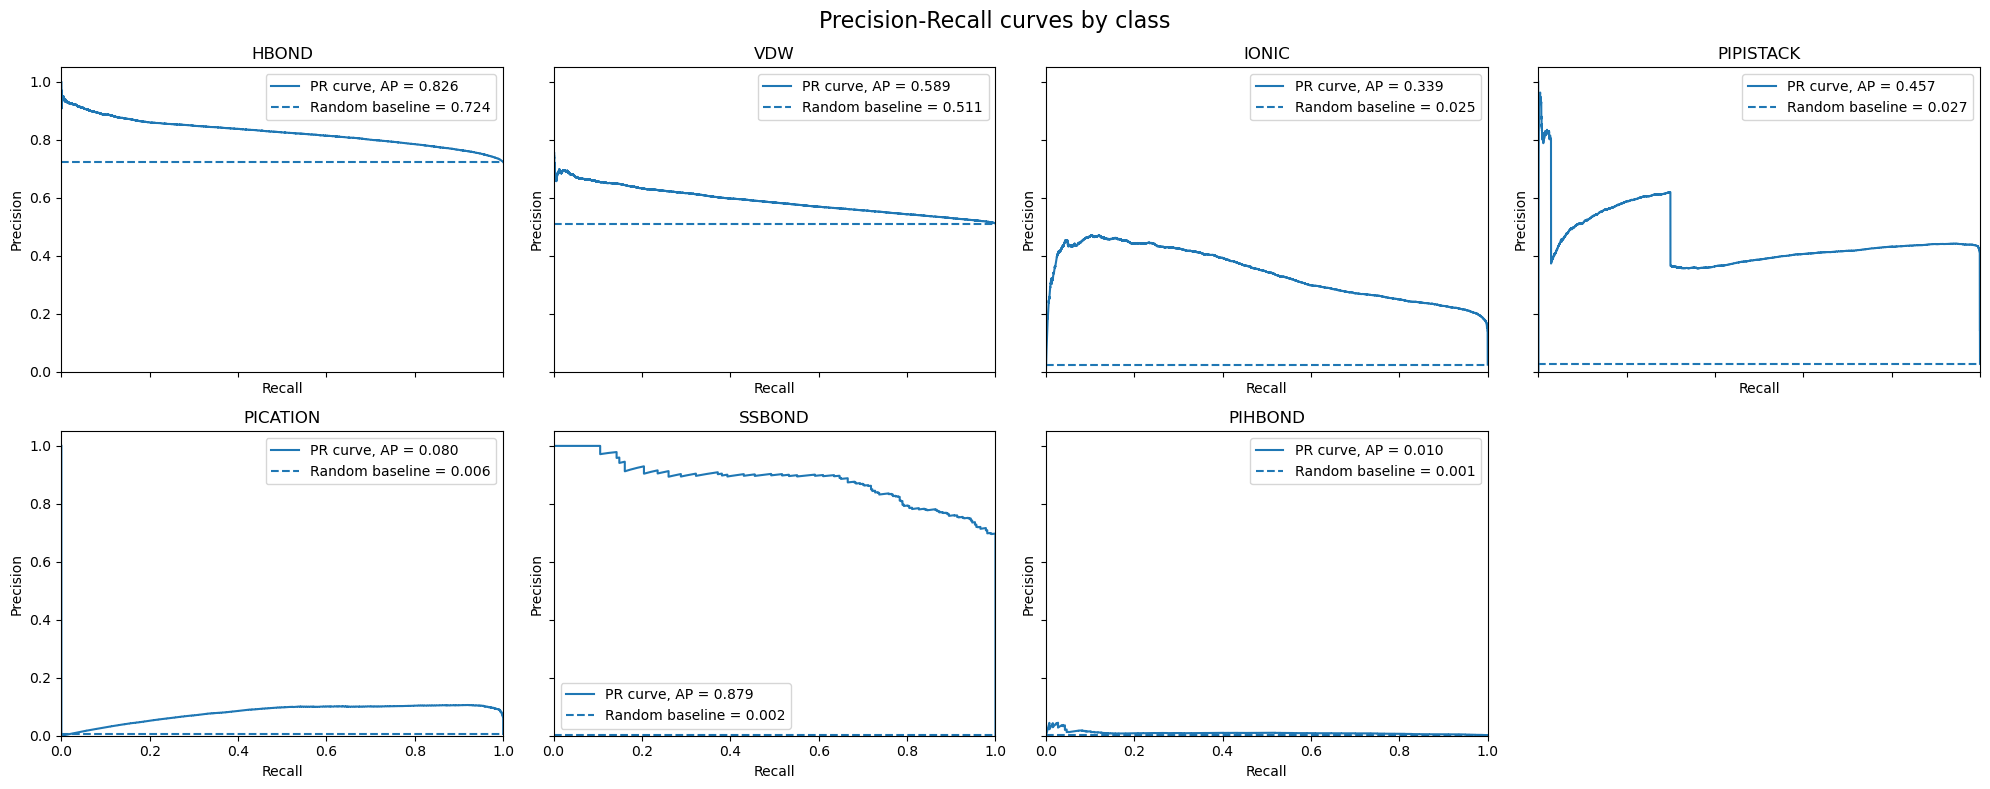

In [15]:
n_classes = len(target_names)

n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    y_score_class = y_scores[:, class_idx]

    precision, recall, thresholds = precision_recall_curve(
        y_true_class,
        y_score_class
    )

    ap = average_precision_score(
        y_true_class,
        y_score_class
    )

    # baseline = prevalence of the positive class
    prevalence = np.mean(y_true_class)

    ax.plot(recall, precision, label=f"PR curve, AP = {ap:.3f}")
    ax.axhline(
        prevalence,
        linestyle="--",
        label=f"Random baseline = {prevalence:.3f}"
    )

    ax.set_title(class_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend()

# remove empty panels
for j in range(n_classes, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Precision-Recall curves by class", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# Compute ROC curves and AUC for each class
roc_results = []

for class_idx, class_name in enumerate(target_names):

    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    y_score_class = y_scores[:, class_idx]

    fpr, tpr, thresholds = roc_curve(
        y_true_class,
        y_score_class
    )

    auc = roc_auc_score(
        y_true_class,
        y_score_class
    )

    for i in range(len(fpr)):
        roc_results.append({
            "class": class_name,
            "fpr": fpr[i],
            "tpr": tpr[i],
            "threshold": thresholds[i],
            "roc_auc": auc
        })

roc_results = pd.DataFrame(roc_results)

roc_auc_scores = roc_results.groupby("class")["roc_auc"].first()
display(roc_auc_scores)

class
HBOND        0.669444
IONIC        0.966814
PICATION     0.968077
PIHBOND      0.905311
PIPISTACK    0.980902
SSBOND       0.999847
VDW          0.590382
Name: roc_auc, dtype: float64

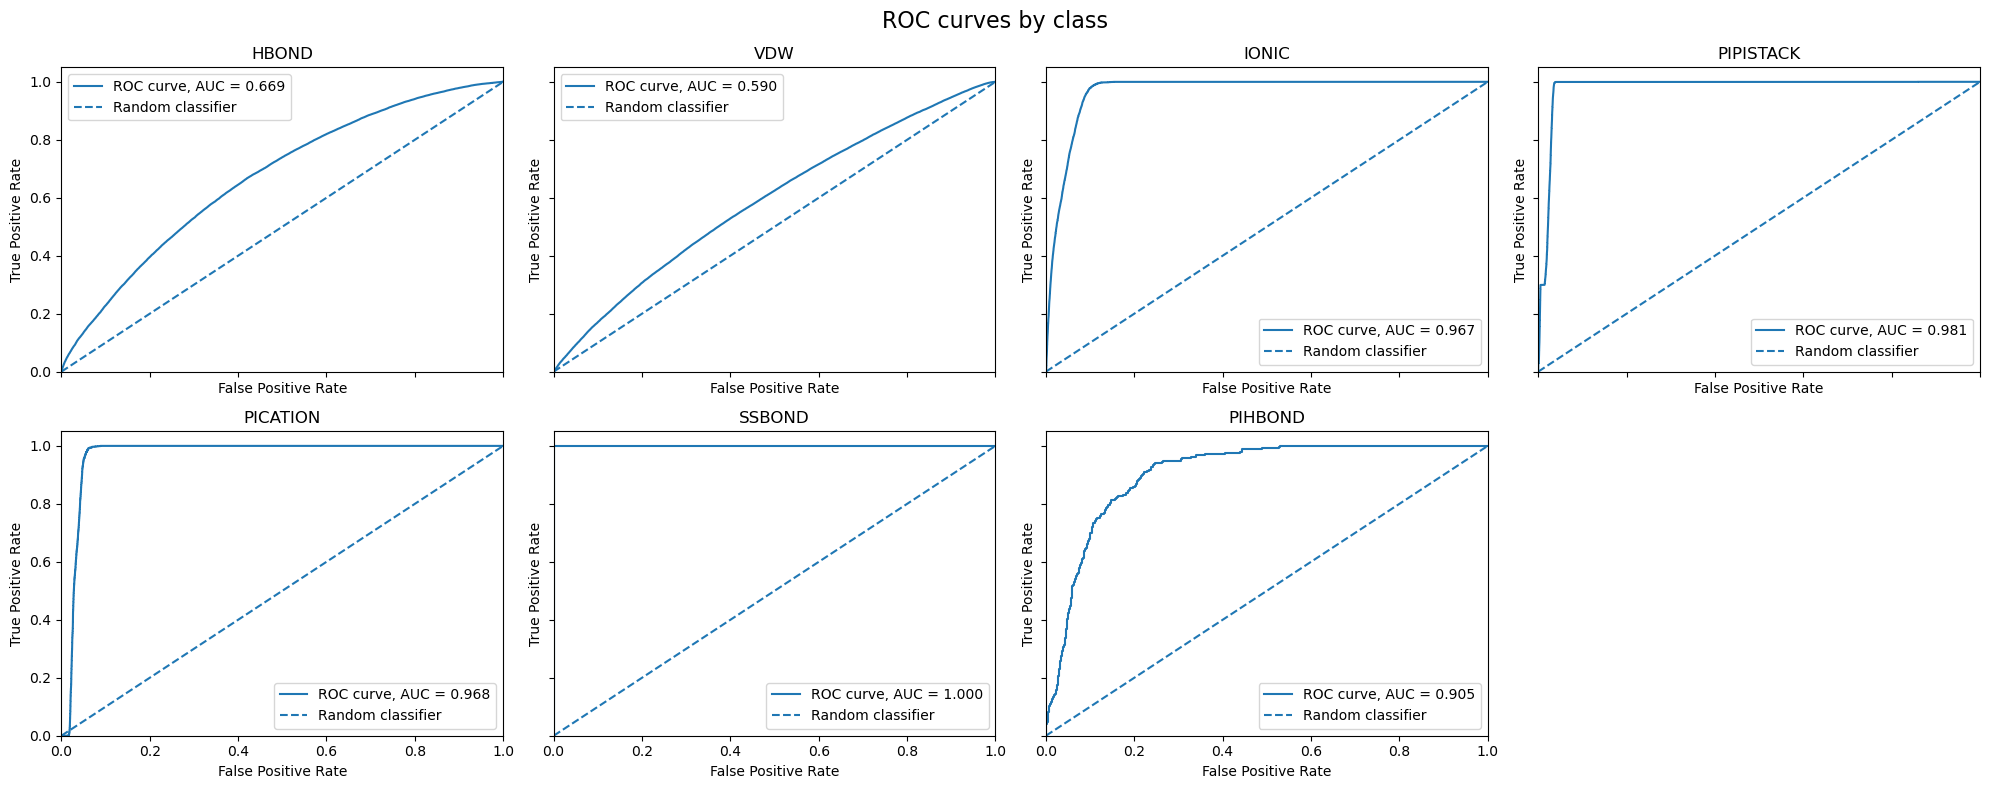

In [17]:
n_classes = len(target_names)

n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    y_score_class = y_scores[:, class_idx]

    fpr, tpr, thresholds = roc_curve(
        y_true_class,
        y_score_class
    )

    auc = roc_auc_score(
        y_true_class,
        y_score_class
    )

    ax.plot(fpr, tpr, label=f"ROC curve, AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], color = "tab:blue", linestyle="--", label="Random classifier")

    ax.set_title(class_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend()

# remove empty panels
for j in range(n_classes, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("ROC curves by class", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
# GROUPED ANALISYS:

# join roc_auc and pr_auc scores into a single dataframe for easier comparison
auc_scores = roc_auc_scores.to_frame().join(average_precision_scores.to_frame(), lsuffix='_roc', rsuffix='_pr')
auc_scores

,roc_auc,average_precision
class,,
HBOND,0.669444,0.825817
IONIC,0.966814,0.338547
PICATION,0.968077,0.079552
PIHBOND,0.905311,0.009740
PIPISTACK,0.980902,0.457302
SSBOND,0.999847,0.879027
VDW,0.590382,0.588912


---
# Diagnostics

Analysis to understand better why we got the results we got

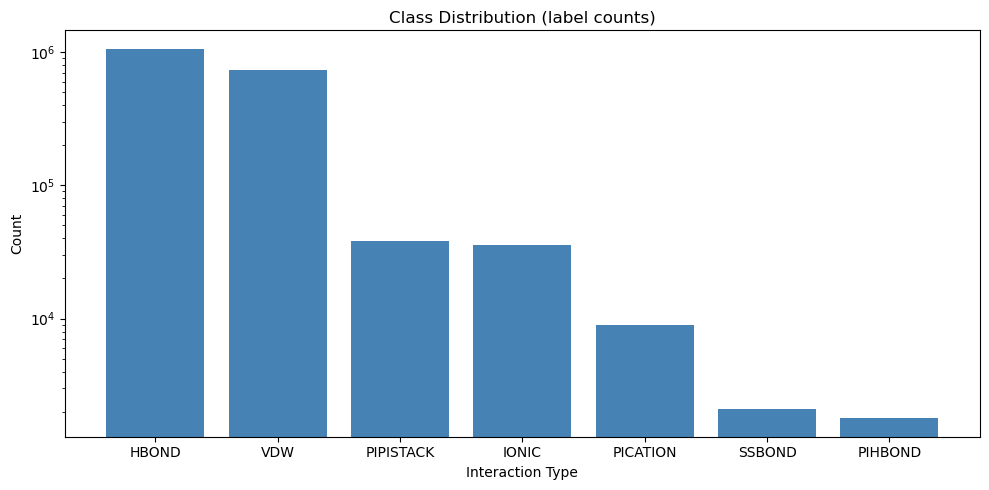

HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


In [19]:
import matplotlib.pyplot as plt

label_counts = df[label_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue')
plt.title("Class Distribution (label counts)")
plt.ylabel("Count")
plt.xlabel("Interaction Type")
plt.yscale('log')#seeing log scale because very imbalanced
plt.tight_layout()
plt.show()

print(label_counts)

Looking at the *scores* distirbutions: which classes are most clearly linearly separated? These plots should complement and confirm the BA plots.

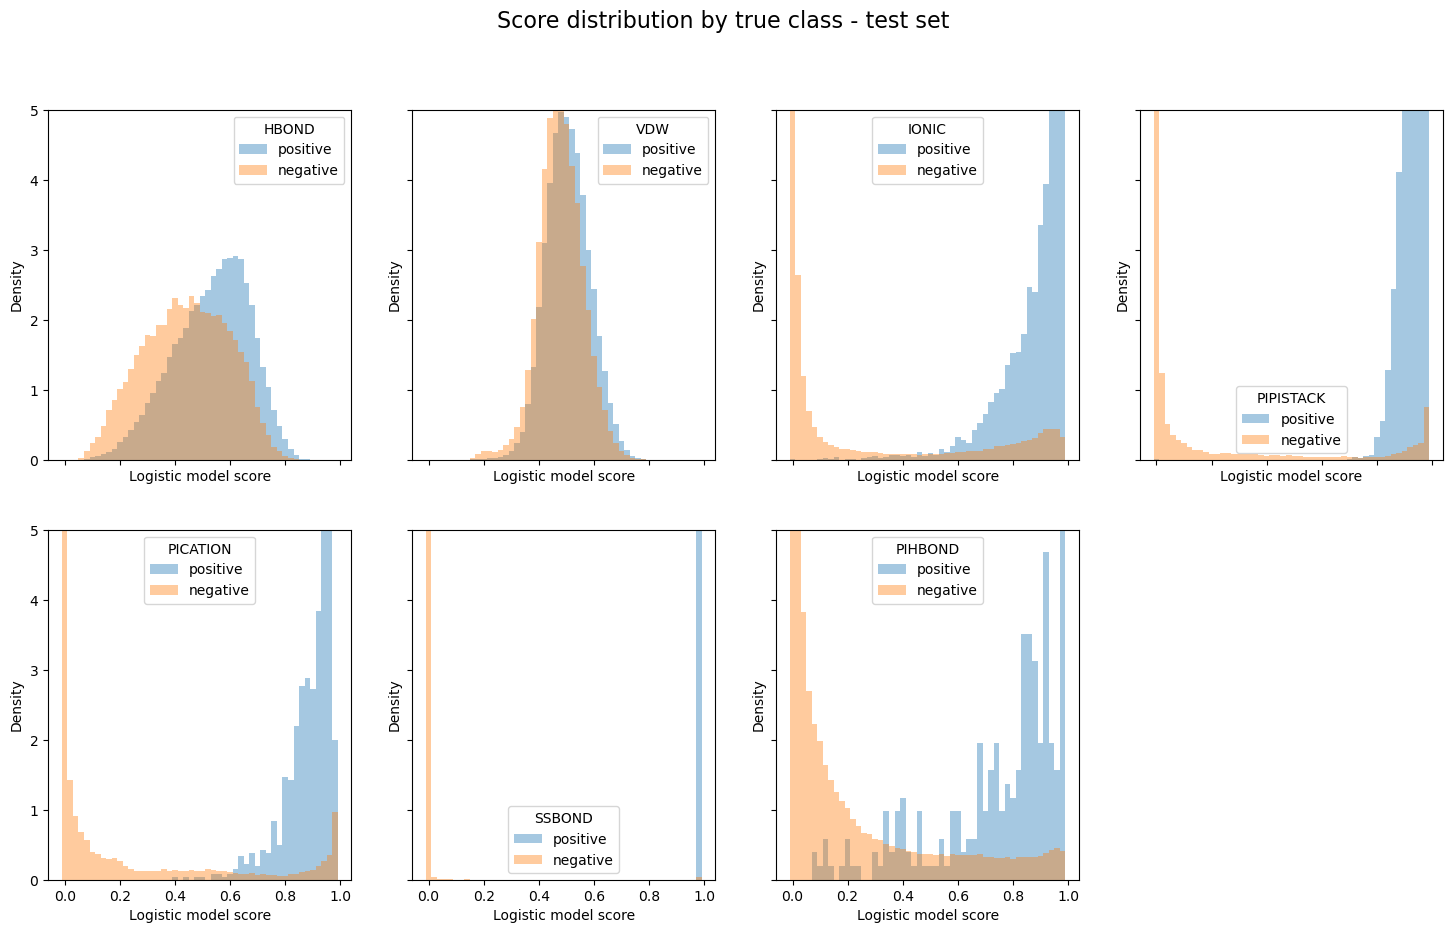

In [26]:

fig, axes = plt.subplots(2, len(target_names)//2 + 1, figsize=(18, 10),
                         sharex=True, sharey=True)

plt.suptitle("Score distribution by true class - test set", fontsize=16)
axes = axes.flatten()
axes[-1].axis('off') 


for class_idx, class_name in enumerate(target_names):
    y_true_class = Y_test.iloc[:, class_idx] if hasattr(Y_test, "iloc") else Y_test[:, class_idx]
    scores = y_scores[:, class_idx]
    positives = scores[y_true_class == 1]
    negatives = scores[y_true_class == 0]
    poscounts, posbins = np.histogram(positives, bins=50, range=(0, 1), density=True)
    negcounts, negbins = np.histogram(negatives, bins=50, range=(0, 1), density=True)
    ax = axes[class_idx]
    ax.bar(posbins[:-1], poscounts, width=np.diff(posbins), label="positive", alpha=0.4)
    ax.bar(negbins[:-1], negcounts, width=np.diff(negbins), label="negative", alpha=0.4)
    ax.set_xlabel("Logistic model score")
    ax.set_ylabel("Density")
    ax.legend(title = f"{target_names[class_idx]}")
    ax.set_ylim(0, 5) # zoom in to look at misclassifications better

plt.show()

**Observations**:


The logistic score is the composition of the sigmoid function with a linear map.
$$
score(x) = \sigma \left(\sum_{i}^{n.features} w_i x_i + w_0 \right)
$$

Separation of the scores shows how well it is possible to perform each binary one-vs-rest classification by using a linear boundary decision.

- SSBOND class is perfectly separated, as it was expected, being the chemistry of the SSBOND totally restrictive.
- PICATION, IONIC, and PIPISTACK are well separated, **but** with a large number of **false positives**. This should be looked into.
    - false positives affect MCC and PR-curve (precision), while they do not affect the balanced accuracy and the ROC. 
    - The fact that the classifier separates quite well positives and negatives, while still producing a lot of false positives, explains perfectly why these classes display low MCC and a low PR-curve, while still having good values of ROC and BA.
- PIHBOND is only moderately separated by a linear boundary.
- VDW and HBOND classes are not separable at all with a linear boundary.


**TODO** *Probably a different kind of IMPUTATION strategy could improve performance - before moving to nonlinear classifiers?*

---
# Next steps- to do
**Inspection of false positives**

TODO: 

- Inspect the false positives

- Some classes may be hard because their labels are not independent. For example, ionic contacts and hydrogen bonds may overlap; aromatic contacts may overlap with pi-stacking or pi-cation patterns.

- For each class, inspect feature separability.
  A simple start is to compare feature means between positives and negatives.


- For a linear model, also inspect coefficients:
    This helps answer:

        * Is the model using chemically meaningful features?
        * Are poor classes associated with weak or diffuse coefficients?
        * Are some classes relying on features that are not class-specific?
        * Are geometric features missing?

**Get model feature weights**

In [21]:
# Extract fitted parts
preprocessor = pipeline.named_steps["preprocessor"]
classifier = pipeline.named_steps["classifier"]

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# One LogisticRegression model per class
estimators = classifier.estimators_

# Store coefficients class by class
coef_tables = {}

for class_idx, class_name in enumerate(target_names):
    model = estimators[class_idx]

    coefs = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values("abs_coefficient", ascending=False)

    coef_tables[class_name] = coef_df

    #print(f"\nTop features for {class_name}")
    #display(coef_df.head(15))

# Inspection of the false positives - class by class

### IONIC CLASS:


Inspecting overlaps, $90\%$ of ionic also are hbonds. Basically, IONIC is a subset of HBOND. This *could* explain why we get so many false positives for IONIC. The check we must make is:


Are the IONIC false positives mostly HBOND-positive?

If yes, then the model may be learning a broader “polar / electrostatic / hydrogen-bond-like contact” signal rather than the more specific ionic interaction signal.

In [27]:
ionic_name = "IONIC"
hbond_name = "HBOND"

ionic_idx = list(target_names).index(ionic_name)
hbond_idx = list(target_names).index(hbond_name)

y_true_ionic = Y_test.iloc[:, ionic_idx] if hasattr(Y_test, "iloc") else Y_test[:, ionic_idx]
y_true_hbond = Y_test.iloc[:, hbond_idx] if hasattr(Y_test, "iloc") else Y_test[:, hbond_idx]

y_score_ionic = y_scores[:, ionic_idx]

# Use the threshold that maximizes MCC for IONIC
ionic_best_threshold = 0.5
 #metric_summary.loc[
    #metric_summary["class"] == ionic_name,
    #"best_MCC_threshold"
#].values[0]

y_pred_ionic = (y_score_ionic >= ionic_best_threshold).astype(int)

fp_ionic = (y_true_ionic == 0) & (y_pred_ionic == 1)
tp_ionic = (y_true_ionic == 1) & (y_pred_ionic == 1)
fn_ionic = (y_true_ionic == 1) & (y_pred_ionic == 0)
tn_ionic = (y_true_ionic == 0) & (y_pred_ionic == 0)

diagnosis = {
    "IONIC false positives": fp_ionic.sum(),
    "IONIC false positives that are HBOND-positive": ((fp_ionic) & (y_true_hbond == 1)).sum(),
    "fraction of IONIC false positives that are HBOND-positive": ((fp_ionic) & (y_true_hbond == 1)).sum() / fp_ionic.sum(),

    "IONIC true positives": tp_ionic.sum(),
    "IONIC true positives that are HBOND-positive": ((tp_ionic) & (y_true_hbond == 1)).sum(),
    "fraction of IONIC true positives that are HBOND-positive": ((tp_ionic) & (y_true_hbond == 1)).sum() / tp_ionic.sum()
}

diagnosis

{'IONIC false positives': np.int64(22184),
 'IONIC false positives that are HBOND-positive': np.int64(18312),
 'fraction of IONIC false positives that are HBOND-positive': np.float64(0.8254597908402452),
 'IONIC true positives': np.int64(5184),
 'IONIC true positives that are HBOND-positive': np.int64(4815),
 'fraction of IONIC true positives that are HBOND-positive': np.float64(0.9288194444444444)}

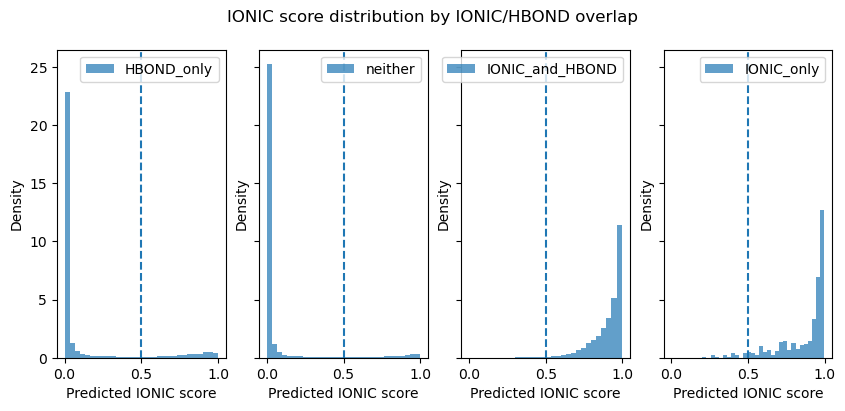

In [40]:
groups = pd.DataFrame({
    "IONIC": y_true_ionic,
    "HBOND": y_true_hbond,
    "IONIC_score": y_score_ionic
})

def assign_group(row):
    if row["IONIC"] == 0 and row["HBOND"] == 0:
        return "neither"
    elif row["IONIC"] == 0 and row["HBOND"] == 1:
        return "HBOND_only"
    elif row["IONIC"] == 1 and row["HBOND"] == 0:
        return "IONIC_only"
    else:
        return "IONIC_and_HBOND"

groups["group"] = groups.apply(assign_group, axis=1)

groups.groupby("group")["IONIC_score"].describe()



fig, axs = plt.subplots(1, 4, figsize=(10, 4), sharey=True, sharex=True)
axs = axs.flatten()
for group_name in ["neither", "HBOND_only", "IONIC_only", "IONIC_and_HBOND"]:
    ax = axs[list(groups["group"].unique()).index(group_name)]
    subset = groups[groups["group"] == group_name]
    if len(subset) > 0:
        ax.hist(
            subset["IONIC_score"],
            bins=30,
            alpha=0.7,
            density=True,
            label=f"{group_name}"
        )
        ax.legend()
    ax.axvline(ionic_best_threshold, linestyle="--", label="Best MCC threshold")
    ax.set_xlabel("Predicted IONIC score")
    ax.set_ylabel("Density")
plt.suptitle("IONIC score distribution by IONIC/HBOND overlap")

plt.show()

Observations:
- actually, the model correclty scores HBOND_only mostly on the low end, meaning it has quite well learned a ionic signal. 
- still, it may have some trouble on the boundary ionic/hbond only, because the two types have common caracteristics, and given the very high prevalence of hbond in the dataset, the misclassification of hbond as also ionic may be the cause that mostly contributes to the FPs.

In [41]:
y_pred_ionic = (y_score_ionic >= 0.5).astype(int)

fp_ionic = (y_true_ionic == 0) & (y_pred_ionic == 1)

hbond_only = (y_true_ionic == 0) & (y_true_hbond == 1)
neither = (y_true_ionic == 0) & (y_true_hbond == 0)


fp_breakdown = pd.DataFrame({
    "FP group": ["HBOND_only", "neither"],
    "n_false_positives": [
        (fp_ionic & hbond_only).sum(),
        (fp_ionic & neither).sum()
    ],
    "fraction_of_all_IONIC_FPs": [
        (fp_ionic & hbond_only).sum() / fp_ionic.sum(),
        (fp_ionic & neither).sum() / fp_ionic.sum()
    ]
})

fp_breakdown

,FP group,n_false_positives,fraction_of_all_IONIC_FPs
0,HBOND_only,18312,0.82546
1,neither,3872,0.17454


Result: HBONDS indeed make up for $85\%$ of IONIC false positives. So now we know what the FPs of this class are due to and can possibly improve the model's ability to distinguish the two.

In [28]:
""""

import matplotlib.pyplot as plt

top_n = 15

for class_name, coef_df in coef_tables.items():

    top_df = (
        coef_df
        .sort_values("abs_coefficient", ascending=False)
        .head(top_n)
        .sort_values("coefficient")
    )

    plt.figure(figsize=(8, 6))
    plt.barh(top_df["feature"], top_df["coefficient"])

    plt.axvline(0, linestyle="--")
    plt.xlabel("Logistic regression coefficient")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} logistic regression weights: {class_name}")

    plt.tight_layout()
    plt.show()
""""

SyntaxError: unterminated string literal (detected at line 26) (3589146844.py, line 26)